# Project 5 — Notebook 17: Manpower & NOC Quality Analysis
### Engineer Workload · ROC Account · Unknown RFO Attribution · Site Coverage

---

| | |
|---|---|
| **Scope** | NCR (Region 3) · Reactive tickets (Priority 1–3) · Engineer-level analysis |
| **Feeds from** | NB16 (Site Risk Profiling) · `output/cleaned_fault_ticket.csv` |
| **Audience** | Operations Leadership / Area Heads |

---

**Questions this notebook answers:**
1. How is NOC/ROC ticket load distributed — and does the ROC team account dominate specific zones or RFO types?
2. Do field engineers with heavier workloads show worse SLA compliance and MTTR?
3. Which engineers are managing the most sites — and is that load sustainable?
4. Where does the Unknown RFO problem originate: specific engineers, zones, or ticket types?

---

**Key data context:**
- `Engineer_ID = 'Unknown'`: 2,325 tickets with no NOC attribution — excluded from engineer analysis
- `Engineer_ID = 'ENG_a2fa1599'`: ROC team account (Regional Operations Centre), not an individual.
  Retained and labelled separately — its 29.9% Unknown RFO rate reflects ROC-specific closure patterns.
- `Field_Lead_ID = 'Unknown'`: ~14,075 tickets — Auto-Restored and NOC-Remote tickets where
  no engineer was dispatched. Expected behavior, not a data gap.
- `WOOwnerGroup` *(new column — requires pipeline re-run)*: Work order owner group,
  normalised to Field Operations / NOC (incl. ROC) / Core Operator / Engineering / Fiber Restoration / Tier 2 Support / Facilities Ops / Third Party / Other.
  This is the correct filter for genuine field engineer analysis — `Field_Lead_ID` alone
  includes NOC/ROC staff who appear as WO leads on non-field-team tickets. Where
  `WOOwnerGroup` is available, field engineer analysis uses `WOOwnerGroup == 'Field Operations'`.

## 1. Setup

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from config import ZONE_ORDER, ZONE_PALETTE

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
df_zone = df[(df['ZONE'].isin(ZONE_ORDER)) & (df['Priority'] < 4)].copy()
df_fd   = df_zone[df_zone['Resolution_Path'] == 'Field_Dispatch_Restored'].copy()

# Separate ROC account from NOC personnel
ROC_ID  = 'ENG_a2fa1599'
df_noc  = df_zone[df_zone['Engineer_ID'] != 'Unknown'].copy()
df_noc_excl_roc = df_noc[df_noc['Engineer_ID'] != ROC_ID].copy()

# Field engineers: FD tickets only, exclude Unknown Field_Lead_ID
# Filter to WOOwnerGroup == 'Field Operations' where available — removes
# NOC/ROC/other-dept personnel appearing as WO leads in FD tickets
df_fe_all = df_fd[df_fd['Field_Lead_ID'] != 'Unknown'].copy()
MIN_FE_TICKETS = 100  # activity threshold — removes incidental/cross-zone assignees

if 'WOOwnerGroup' in df_fe_all.columns:
    # Step 1 — Field Operations WOs only
    _fe_fo = df_fe_all[df_fe_all['WOOwnerGroup'] == 'Field Operations'].copy()
    print(f'FD tickets with attributed Field_Lead_ID: {len(df_fe_all):,}')
    print(f'  Field Operations WOs:  {len(_fe_fo):,}')
    print(f'  Other dept WOs in FD:  {len(df_fe_all)-len(_fe_fo):,} '
          f'(NOC/ROC/other — see Section 6)')
    # Step 2 — Zone alignment: keep engineer in the zone where they work most
    _home = (_fe_fo.groupby('Field_Lead_ID')['ZONE']
        .agg(lambda x: x.mode()[0]).rename('Home_Zone').reset_index())
    _fe_fo = _fe_fo.merge(_home, on='Field_Lead_ID', how='left')
    _fe_fo = _fe_fo[_fe_fo['ZONE'] == _fe_fo['Home_Zone']].copy()
    # Step 3 — Activity threshold: ≥100 tickets in home zone
    _zc  = _fe_fo.groupby(['ZONE','Field_Lead_ID']).size().reset_index(name='_tc')
    _act = _zc[_zc['_tc'] >= MIN_FE_TICKETS][['ZONE','Field_Lead_ID']]
    df_fe = _fe_fo.merge(_act, on=['ZONE','Field_Lead_ID'], how='inner').copy()
    print(f'  After zone-alignment + ≥{MIN_FE_TICKETS} ticket threshold:')
    for _z in ZONE_ORDER:
        _n = df_fe[df_fe['ZONE']==_z]['Field_Lead_ID'].nunique()
        print(f'    {_z}: {_n} engineers')
else:
    df_fe = df_fe_all
    print('⚠ WOOwnerGroup not in data — pipeline re-run required for accurate engineer counts.')
    print(f'  Using all FD tickets with Field_Lead_ID: {len(df_fe):,}')

print(f"✅ Reactive tickets: {len(df_zone):,}")
print(f"   NOC tickets (excl. Unknown): {len(df_noc):,}")
print(f"     of which ROC account ({ROC_ID}): {(df_noc['Engineer_ID']==ROC_ID).sum():,}")
print(f"     individual NOC engineers:         {len(df_noc_excl_roc):,}")
print(f"   Unknown Engineer_ID (excluded):    {(df_zone['Engineer_ID']=='Unknown').sum():,}")
print()
print(f"   FD tickets (field dispatched):     {len(df_fd):,}")
print(f"   FD with engineer attributed:       {len(df_fe):,}")
print(f"   FD Unknown Field_Lead (expected):  {len(df_fd)-len(df_fe):,}")

FD tickets with attributed Field_Lead_ID: 22,822
  Field Operations WOs:  19,787
  Other dept WOs in FD:  3,035 (NOC/ROC/other — see Section 6)
  After zone-alignment + ≥100 ticket threshold:
    ZONE 1: 8 engineers
    ZONE 2: 15 engineers
    ZONE 3: 10 engineers
    ZONE 4: 15 engineers
    ZONE 5: 19 engineers
    ZONE 6: 8 engineers
✅ Reactive tickets: 36,907
   NOC tickets (excl. Unknown): 34,582
     of which ROC account (ENG_a2fa1599): 8,518
     individual NOC engineers:         26,064
   Unknown Engineer_ID (excluded):    2,325

   FD tickets (field dispatched):     22,822
   FD with engineer attributed:       17,703
   FD Unknown Field_Lead (expected):  5,119


## 2. NOC Personnel Analysis

> Ticket load and RFO quality per NOC engineer.
> The ROC team account (`ENG_a2fa1599`) is treated separately — it represents a team,
> not an individual, and its UNKNOWN RFO rate (29.9%) reflects ROC-specific patterns.
>
> **Issuer_Team column** identifies whether a ticket was issued by NOC or ROC — this
> supplements the Engineer_ID analysis.

NOC/ROC ticket distribution:
  ROC account (ENG_a2fa1599): 8,518 tickets (24.6%)
  Individual NOC engineers: 26,064 tickets (75.4%)
  Total NOC engineers (excl. Unknown): 115  (includes ROC account as 1)

Tickets by Issuer_Team:
Issuer_Team
NOC    36907


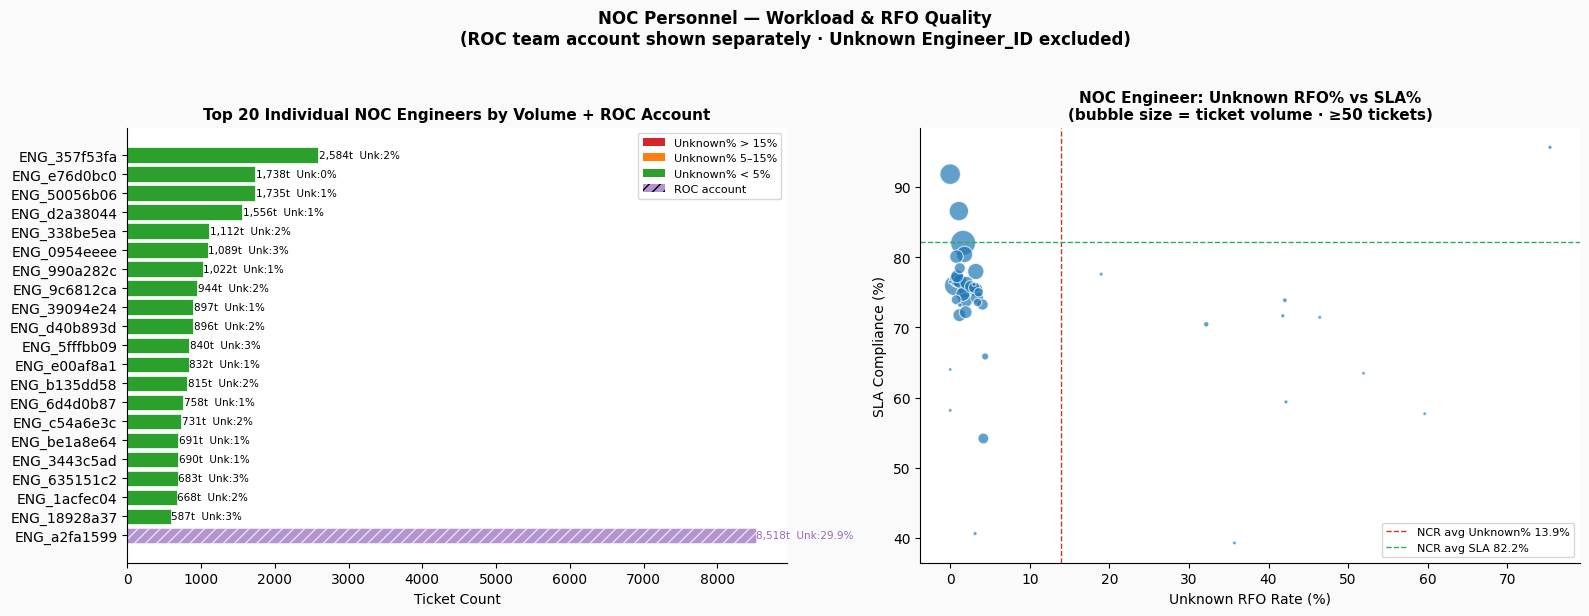

In [2]:
# NOC personnel summary
noc_stats = (df_noc.groupby('Engineer_ID')
    .agg(
        Tickets     = ('SLA_Compliant',   'count'),
        SLA_pct     = ('SLA_Compliant',   'mean'),
        Unknown_pct = ('Standardized RFO',
                       lambda x:(x=='UNKNOWN-Under Investigation').sum()/len(x)*100),
        Zones       = ('ZONE',            lambda x: ', '.join(sorted(x.unique()))),
        Teams       = ('Issuer_Team',     lambda x: x.mode()[0]),
    )
    .reset_index()
    .sort_values('Tickets', ascending=False)
)
noc_stats['SLA_pct'] *= 100

# Flag ROC account
noc_stats['Is_ROC'] = noc_stats['Engineer_ID'] == ROC_ID

# NOC vs ROC ticket split
noc_total = len(df_noc)
roc_tickets = noc_stats[noc_stats['Is_ROC']]['Tickets'].values[0]
print(f"NOC/ROC ticket distribution:")
print(f"  ROC account ({ROC_ID}): {roc_tickets:,} tickets ({roc_tickets/noc_total*100:.1f}%)")
print(f"  Individual NOC engineers: {noc_total-roc_tickets:,} tickets ({(noc_total-roc_tickets)/noc_total*100:.1f}%)")
print(f"  Total NOC engineers (excl. Unknown): {len(noc_stats):,}  "
      f"(includes ROC account as 1)")

# Issuer team split
print(f"\nTickets by Issuer_Team:")
print(df_zone['Issuer_Team'].value_counts().to_string())

# Visualise: NOC load distribution (excl. ROC) + Unknown RFO rate
noc_ind = noc_stats[~noc_stats['Is_ROC']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#fafafa')
fig.suptitle('NOC Personnel — Workload & RFO Quality\n'
             '(ROC team account shown separately · Unknown Engineer_ID excluded)',
             fontsize=12, fontweight='bold', y=1.02)

# [Left] Ticket load — top 20 individual NOC engineers
top20_noc = noc_ind.head(20)
bar_colors = ['#d62728' if u > 15 else '#ff7f0e' if u > 5 else '#2ca02c'
               for u in top20_noc['Unknown_pct']]
bars = axes[0].barh(top20_noc['Engineer_ID'], top20_noc['Tickets'],
                     color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val, unk in zip(bars, top20_noc['Tickets'], top20_noc['Unknown_pct']):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                  f'{val:,}t  Unk:{unk:.0f}%', va='center', fontsize=7.5)

# Add ROC account as separate bar at bottom with different hatch
axes[0].barh([ROC_ID], [roc_tickets], color='#9467bd',
              edgecolor='white', linewidth=0.5, hatch='///', alpha=0.7,
              label=f'ROC account  ({roc_tickets:,}t · 29.9% Unk%)')
axes[0].text(roc_tickets + 10, 20, f'{roc_tickets:,}t  Unk:29.9%',
              va='center', fontsize=7.5, color='#9467bd')

axes[0].set_title('Top 20 Individual NOC Engineers by Volume + ROC Account',
                   fontsize=11, fontweight='bold', pad=6)
axes[0].set_xlabel('Ticket Count', fontsize=10)
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

leg_els = [mpatches.Patch(facecolor='#d62728', label='Unknown% > 15%'),
            mpatches.Patch(facecolor='#ff7f0e', label='Unknown% 5–15%'),
            mpatches.Patch(facecolor='#2ca02c', label='Unknown% < 5%'),
            mpatches.Patch(facecolor='#9467bd', hatch='///', label='ROC account', alpha=0.7)]
axes[0].legend(handles=leg_els, fontsize=8, loc='upper right')

# [Right] Unknown RFO rate vs SLA rate scatter (individual NOC only, ≥50 tickets)
noc_sig = noc_ind[noc_ind['Tickets'] >= 50]
scatter = axes[1].scatter(noc_sig['Unknown_pct'], noc_sig['SLA_pct'],
                           s=noc_sig['Tickets']/8, alpha=0.7,
                           c='#1f77b4', edgecolors='white', linewidth=0.8)
ncr_unk = (df_zone['Standardized RFO']=='UNKNOWN-Under Investigation').mean()*100
ncr_sla = df_zone['SLA_Compliant'].mean()*100
axes[1].axvline(ncr_unk, color='#c0392b', linestyle='--', linewidth=1,
                 label=f'NCR avg Unknown% {ncr_unk:.1f}%')
axes[1].axhline(ncr_sla, color='#27ae60', linestyle='--', linewidth=1,
                 label=f'NCR avg SLA {ncr_sla:.1f}%')
axes[1].set_xlabel('Unknown RFO Rate (%)', fontsize=10)
axes[1].set_ylabel('SLA Compliance (%)', fontsize=10)
axes[1].set_title('NOC Engineer: Unknown RFO% vs SLA%\n'
                   '(bubble size = ticket volume · ≥50 tickets)',
                   fontsize=11, fontweight='bold', pad=6)
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project5_ncr/17_noc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ROC Account — Zone and RFO Distribution

> The ROC (Regional Operations Centre) account `ENG_a2fa1599` logged 8,518 tickets —
> 23% of all NCR reactive tickets. This section identifies which zones and RFO types
> it predominantly handles, and whether its 29.9% Unknown RFO rate is concentrated
> in specific scenarios (e.g., tickets tagged 'Under Investigation' that were never updated).
>
> **Note on San Juan City:** The city shows 38.2h average NOC/ROC time and 63.7% Unknown RFO —
> both extreme outliers for Zone 4. This section checks whether ROC ticket concentration
> in San Juan City explains this anomaly. San Juan RFO analysis is unreliable and excluded
> from city-level RFO recommendations.

ROC account — zone distribution:
ZONE
ZONE 5    2206
ZONE 4    1903
ZONE 2    1868
ZONE 1    1102
ZONE 6    1007
ZONE 3     432

ROC account — top 10 RFO categories:
  FACILITIES-Power Failure                      3,335 (39.2%)
  UNKNOWN-Under Investigation                   2,547 (29.9%)
  TRANSMISSION-IP Network Problem               1,232 (14.5%)
  EQUIPMENT-Defective Hardware                    812 (9.5%)
  ADMIN-Lessor Related Cause                      329 (3.9%)
  FOC CUT - LINEAR                                 59 (0.7%)
  TRANSMISSION-Microwave Antenna System Problem    40 (0.5%)
  TRANSMISSION-Offnetwork                          36 (0.4%)
  THIRD PARTY-Activity Related                     32 (0.4%)
  TRANSMISSION-Fiber Problem                       25 (0.3%)

San Juan City — Issuer_Team breakdown:
Issuer_Team
NOC    1451

San Juan City — Engineer_ID breakdown (top 5):
Engineer_ID
Unknown         836
ENG_a2fa1599    146
ENG_e76d0bc0     38
ENG_b5d1cf6f     27
ENG_357f53fa     

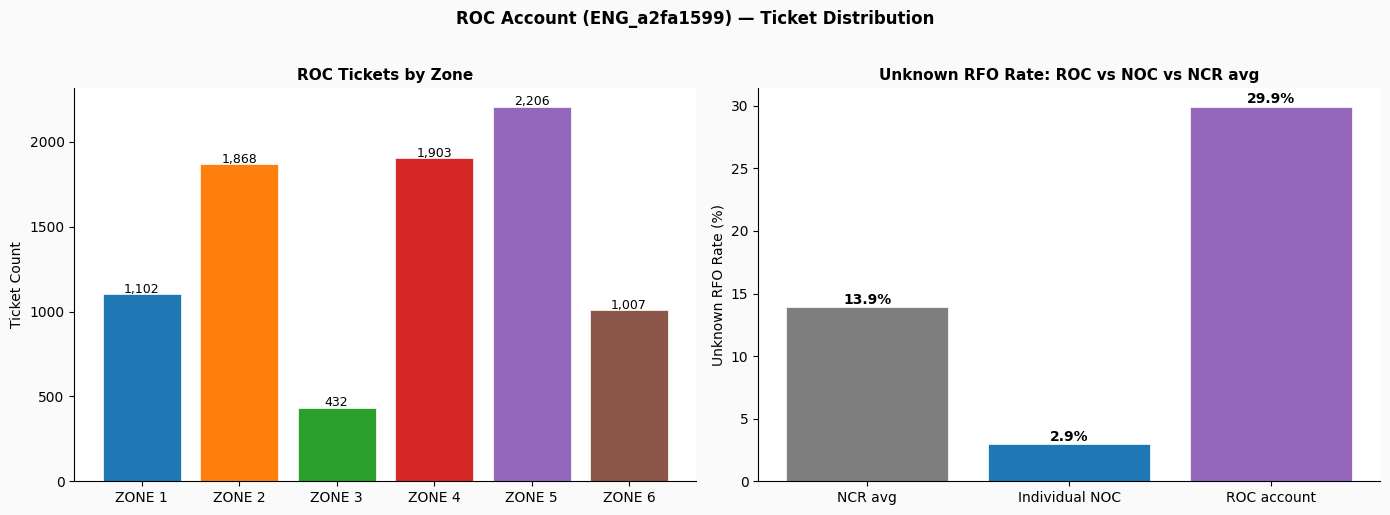

In [3]:
roc_tickets_df = df_zone[df_zone['Engineer_ID'] == ROC_ID].copy()

print(f"ROC account — zone distribution:")
print(roc_tickets_df['ZONE'].value_counts().to_string())

print(f"\nROC account — top 10 RFO categories:")
rfo_split = roc_tickets_df['Standardized RFO'].value_counts().head(10)
for rfo, cnt in rfo_split.items():
    pct = cnt/len(roc_tickets_df)*100
    print(f"  {rfo:<45} {cnt:>5,} ({pct:.1f}%)")

# San Juan City connection
print(f"\nSan Juan City — Issuer_Team breakdown:")
sjc = df_zone[(df_zone['CITY']=='SAN JUAN CITY')]
print(sjc['Issuer_Team'].value_counts().to_string())
print(f"\nSan Juan City — Engineer_ID breakdown (top 5):")
print(sjc['Engineer_ID'].value_counts().head().to_string())
print(f"\nSan Juan City — Unknown RFO: "
      f"{(sjc['Standardized RFO']=='UNKNOWN-Under Investigation').sum():,} "
      f"of {len(sjc):,} tickets ({(sjc['Standardized RFO']=='UNKNOWN-Under Investigation').mean()*100:.1f}%)")
print("⚠ San Juan City RFO analysis is unreliable — excluded from city-level RFO recommendations.")

# Visualise ROC zone distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#fafafa')
fig.suptitle(f'ROC Account ({ROC_ID}) — Ticket Distribution',
              fontsize=12, fontweight='bold', y=1.02)

zone_dist = roc_tickets_df['ZONE'].value_counts().reindex(ZONE_ORDER, fill_value=0)
colors = [ZONE_PALETTE[z] for z in zone_dist.index]
bars = axes[0].bar(zone_dist.index, zone_dist.values, color=colors,
                    edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, zone_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                  f'{val:,}', ha='center', fontsize=9)
axes[0].set_title('ROC Tickets by Zone', fontsize=11, fontweight='bold', pad=6)
axes[0].set_ylabel('Ticket Count', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Unknown RFO rate: ROC vs NOC vs NCR avg
categories = ['NCR avg', 'Individual NOC', 'ROC account']
values = [
    (df_zone['Standardized RFO']=='UNKNOWN-Under Investigation').mean()*100,
    (df_noc_excl_roc['Standardized RFO']=='UNKNOWN-Under Investigation').mean()*100,
    (roc_tickets_df['Standardized RFO']=='UNKNOWN-Under Investigation').mean()*100,
]
bar_colors2 = ['#7f7f7f', '#1f77b4', '#9467bd']
bars2 = axes[1].bar(categories, values, color=bar_colors2, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Unknown RFO Rate: ROC vs NOC vs NCR avg', fontsize=11, fontweight='bold', pad=6)
axes[1].set_ylabel('Unknown RFO Rate (%)', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project5_ncr/17_roc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Field Engineer Load vs Performance

> After applying zone-alignment (home zone = modal zone) and an activity threshold of
> ≥100 tickets, the 75 active field engineers show **Gini coefficients of 0.141–0.229**
> across all zones — indicating moderate-to-low load concentration. Workloads are
> reasonably balanced: median 203–282 tickets, maximum 319–547 per engineer,
> and no engineers exceed 2× their zone median site count.
>
> This section tests whether engineers with higher ticket loads show worse SLA
> compliance and MTTR — and whether the balanced distribution translates to
> consistent performance across the load spectrum.

Load group vs performance (all zones combined):
  Low load    :   20 engineers  median tickets:    136  avg SLA:  76.9%  avg MTTR:    67h  avg sites:  49.1
  Mid load    :   35 engineers  median tickets:    223  avg SLA:  76.3%  avg MTTR:    82h  avg sites:  58.6
  High load   :   20 engineers  median tickets:    326  avg SLA:  75.5%  avg MTTR:    66h  avg sites:  71.2


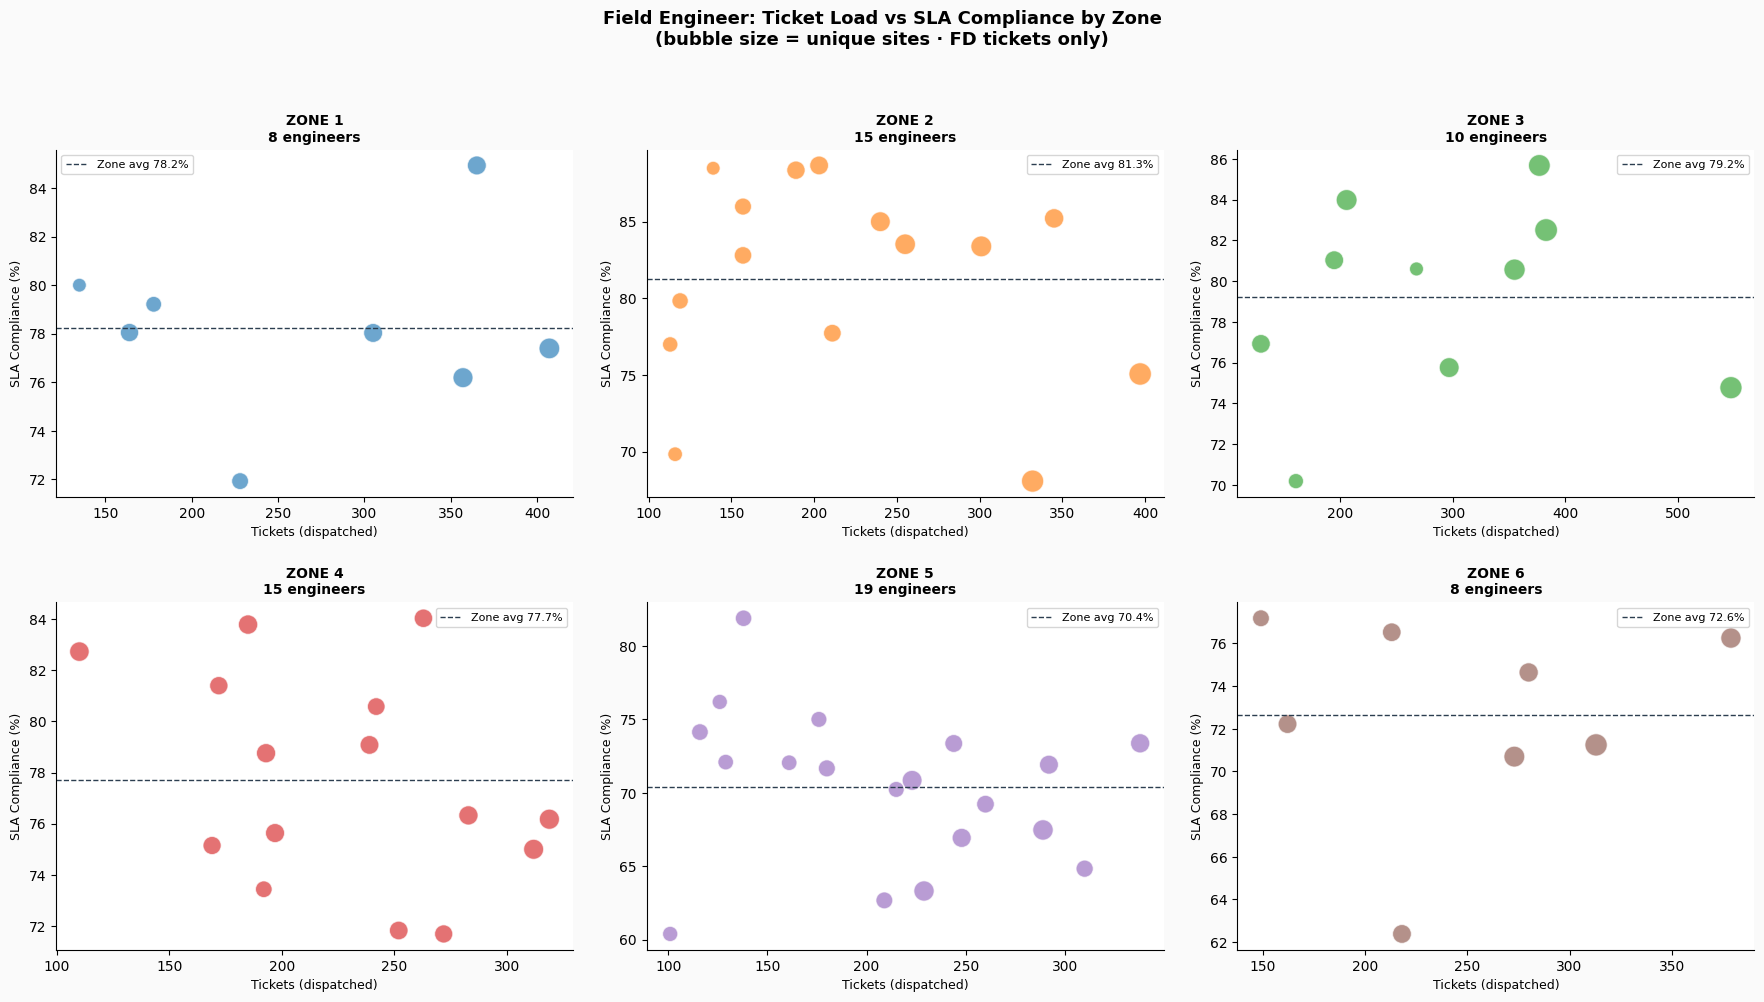


Field engineer load distribution (zone-aligned, ≥100 tickets):
  Zone      Engrs   Med_t   Max_t    Gini  Med_sites  Avg_SLA
  ZONE 1        8     266     407   0.206         60    78.2%
  ZONE 2       15     203     397   0.226         58    81.3%
  ZONE 3       10     282     547   0.229         72    79.2%
  ZONE 4       15     239     319   0.141         61    77.7%
  ZONE 5       19     215     338   0.187         50    70.4%
  ZONE 6        8     246     379   0.165         62    72.6%

  Engineers with site count > 2× zone median:
  None — no engineers exceed 2× zone median in any zone


In [4]:
fe_stats = (df_fe.groupby(['ZONE','Field_Lead_ID'])
    .agg(
        Tickets      = ('SLA_Compliant',  'count'),
        SLA_pct      = ('SLA_Compliant',  'mean'),
        Avg_MTTR     = ('OUTAGEDURATION', 'mean'),
        Unique_Sites = ('SiteName',       'nunique'),
    )
    .reset_index()
)
fe_stats['SLA_pct'] *= 100

# Quartile grouping within zone
def load_quartile(group):
    q = group['Tickets'].quantile([0.25, 0.75])
    group = group.copy()
    group['Load_Group'] = group['Tickets'].apply(
        lambda x: 'High load' if x >= q[0.75] else
                  'Low load'  if x <= q[0.25] else 'Mid load'
    )
    return group

fe_stats = (fe_stats
    .groupby('ZONE', group_keys=False)
    .apply(load_quartile, include_groups=False)
    .reset_index(drop=True))
# ZONE was excluded by include_groups=False — re-derive from fe_stats source
fe_stats['ZONE'] = (fe_stats['Field_Lead_ID']
    .map(df_fe.groupby('Field_Lead_ID')['ZONE'].agg(lambda x: x.mode()[0])))

# Compare SLA and MTTR by load group
print("Load group vs performance (all zones combined):")
for grp in ['Low load','Mid load','High load']:
    g = fe_stats[fe_stats['Load_Group']==grp]
    print(f"  {grp:<12}: {len(g):>4} engineers  "
          f"median tickets: {g['Tickets'].median():>6.0f}  "
          f"avg SLA: {g['SLA_pct'].mean():>5.1f}%  "
          f"avg MTTR: {g['Avg_MTTR'].mean():>5.0f}h  "
          f"avg sites: {g['Unique_Sites'].mean():>5.1f}")

# Scatter: tickets vs SLA by zone
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#fafafa')
fig.suptitle('Field Engineer: Ticket Load vs SLA Compliance by Zone\n'
             '(bubble size = unique sites · FD tickets only)',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax_i, zone in enumerate(ZONE_ORDER):
    zfe = fe_stats[fe_stats['ZONE']==zone]
    if zfe.empty:
        continue
    zone_sla = zfe['SLA_pct'].mean()
    sc = axes[ax_i].scatter(
        zfe['Tickets'], zfe['SLA_pct'],
        s=np.clip(zfe['Unique_Sites']*3, 20, 400),
        c=[ZONE_PALETTE[zone]]*len(zfe),
        alpha=0.65, edgecolors='white', linewidth=0.8
    )
    axes[ax_i].axhline(zone_sla, color='#2c3e50', linestyle='--', linewidth=1,
                         label=f'Zone avg {zone_sla:.1f}%')
    axes[ax_i].set_title(f'{zone}\n{len(zfe)} engineers',
                          fontsize=10, fontweight='bold', pad=6)
    axes[ax_i].set_xlabel('Tickets (dispatched)', fontsize=9)
    axes[ax_i].set_ylabel('SLA Compliance (%)', fontsize=9)
    axes[ax_i].legend(fontsize=8)
    axes[ax_i].spines['top'].set_visible(False)
    axes[ax_i].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('reports/figures/project5_ncr/17_fe_load_sla.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gini summary table ────────────────────────────────────────────────
def gini(arr):
    arr = np.sort(arr.astype(float))
    n = len(arr)
    if n < 2 or arr.sum() == 0: return 0.0
    return (2 * np.sum(np.arange(1, n+1) * arr) / (n * arr.sum())) - (n+1)/n

print("\nField engineer load distribution (zone-aligned, ≥100 tickets):")
print(f"  {'Zone':<8} {'Engrs':>6} {'Med_t':>7} {'Max_t':>7} {'Gini':>7} "
      f"{'Med_sites':>10} {'Avg_SLA':>8}")
for zone in ZONE_ORDER:
    z = fe_stats[fe_stats['ZONE'] == zone]
    if z.empty: continue
    g = gini(z['Tickets'].values)
    print(f"  {zone:<8} {len(z):>6} {z['Tickets'].median():>7.0f} "
          f"{z['Tickets'].max():>7} {g:>7.3f} "
          f"{z['Unique_Sites'].median():>10.0f} {z['SLA_pct'].mean():>7.1f}%")

# Engineers with site count > 2× zone median
print(f"\n  Engineers with site count > 2× zone median:")
any_flagged = False
fe_sites = (df_fe.groupby(['ZONE','Field_Lead_ID'])
    .agg(Sites=('SiteName','nunique'), Tickets=('SLA_Compliant','count'),
         SLA_pct=('SLA_Compliant','mean'))
    .reset_index())
fe_sites['SLA_pct'] *= 100
for zone in ZONE_ORDER:
    z = fe_sites[fe_sites['ZONE'] == zone]
    if z.empty: continue
    med = z['Sites'].median()
    high = z[z['Sites'] > med * 2].sort_values('Sites', ascending=False)
    if not high.empty:
        any_flagged = True
        print(f"  {zone} (median {med:.0f} sites):")
        for _, r in high.head(5).iterrows():
            print(f"    {r['Field_Lead_ID']:<20}  {int(r['Sites']):>4} sites  "
                  f"{int(r['Tickets']):>5,} tickets  SLA: {r['SLA_pct']:.1f}%")
if not any_flagged:
    print(f"  None — no engineers exceed 2× zone median in any zone")


## 5. Engineer–Site Coverage

> Under the operations strategy, each field engineer is the primary responder for their assigned sites.
> This section identifies engineers with unusually high site coverage — where a single engineer
> is responsible for too many sites to maintain consistent response quality on day-off endorsements.
>
> Engineers with very high site counts relative to zone peers may be the bottleneck in the
> endorsement chain: when they are on day off, more sites require team lead escalation.

Zone      Engineers  Median_sites  Max_sites  P90_sites  Avg_t/site
ZONE 1            8            60         74         70         4.6
ZONE 2           15            58         87         81         3.6
ZONE 3           10            72         89         85         4.4
ZONE 4           15            61         70         68         3.7
ZONE 5           19            50         72         69         3.9
ZONE 6            8            62         86         78         3.7


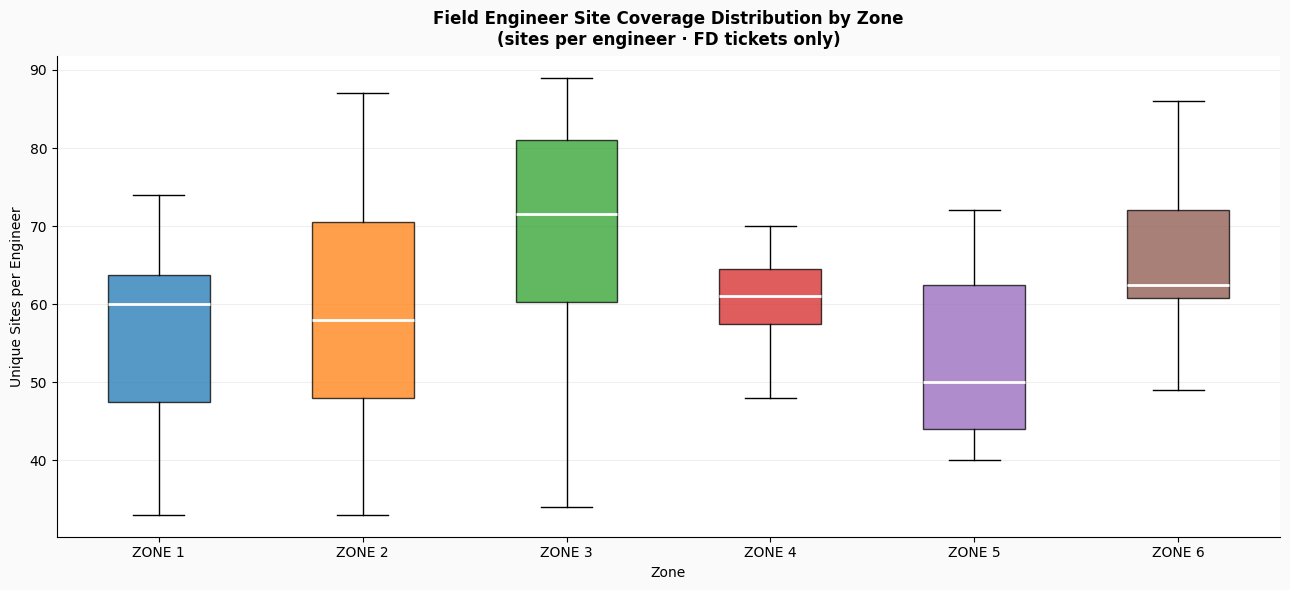


Engineers with site count > 2× zone median (potential endorsement bottleneck):


In [5]:
fe_site_coverage = (df_fe.groupby(['ZONE','Field_Lead_ID'])
    .agg(
        Sites   = ('SiteName',      'nunique'),
        Tickets = ('SLA_Compliant', 'count'),
        SLA_pct = ('SLA_Compliant', 'mean'),
    )
    .reset_index()
)
fe_site_coverage['SLA_pct'] *= 100
fe_site_coverage['Tickets_per_Site'] = (fe_site_coverage['Tickets'] /
                                         fe_site_coverage['Sites'])

# Zone-level site coverage stats
print(f"{'Zone':<8} {'Engineers':>10} {'Median_sites':>13} {'Max_sites':>10} "
      f"{'P90_sites':>10} {'Avg_t/site':>11}")
for zone in ZONE_ORDER:
    zc = fe_site_coverage[fe_site_coverage['ZONE']==zone]
    if zc.empty: continue
    print(f"{zone:<8} {len(zc):>10} {zc['Sites'].median():>13.0f} "
          f"{zc['Sites'].max():>10} "
          f"{zc['Sites'].quantile(0.9):>10.0f} "
          f"{zc['Tickets_per_Site'].mean():>11.1f}")

# Plot: site coverage distribution per zone (boxplot)
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#fafafa')

zone_data = [fe_site_coverage[fe_site_coverage['ZONE']==z]['Sites'].values
              for z in ZONE_ORDER]
bp = ax.boxplot(zone_data, tick_labels=ZONE_ORDER, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
for patch, zone in zip(bp['boxes'], ZONE_ORDER):
    patch.set_facecolor(ZONE_PALETTE[zone])
    patch.set_alpha(0.75)

ax.set_title('Field Engineer Site Coverage Distribution by Zone\n'
              '(sites per engineer · FD tickets only)',
              fontsize=12, fontweight='bold', pad=8)
ax.set_ylabel('Unique Sites per Engineer', fontsize=10)
ax.set_xlabel('Zone', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('reports/figures/project5_ncr/17_fe_site_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag high-coverage engineers (>2× zone median)
print("\nEngineers with site count > 2× zone median (potential endorsement bottleneck):")
for zone in ZONE_ORDER:
    zc = fe_site_coverage[fe_site_coverage['ZONE']==zone]
    med = zc['Sites'].median()
    high = zc[zc['Sites'] > med * 2].sort_values('Sites', ascending=False)
    if high.empty: continue
    print(f"\n  {zone}  (zone median: {med:.0f} sites)")
    for _, r in high.head(5).iterrows():
        print(f"    {r['Field_Lead_ID']:<20}  {int(r['Sites']):>4} sites  "
              f"{int(r['Tickets']):>5,} tickets  SLA: {r['SLA_pct']:.1f}%")

## 6. Non-Field Groups in Field Dispatch Path

> Of 22,822 Field_Dispatch_Restored tickets, **3,035 (13.3%)** are assigned to WO groups
> outside Field Operations. The breakdown:
>
> | Group | FD Tickets |
> |-------|-----------|
> | NOC | 1,363 |
> | Fiber Restoration | 820 |
> | Core Operations | 500 |
> | Engineering | 209 |
> | Facilities Operations | 83 |
> | Tier 2 Support | 59 |
> | Enterprise Operations | 1 |
>
> Where this is a routing issue (tickets dispatched to the wrong WO group), the
> dispatch workflow should be corrected. Where it reflects legitimate cross-team
> support (e.g. Fiber Restoration handling FOC cuts), it should be documented so
> accountability is tracked correctly against the responsible team.

FD tickets with attributed Field_Lead_ID: 22,822
  Field Operations groups:  19,787
  Non-FO groups in FD path: 3,035  (13.3%)

Non-FO groups breakdown by WOOwnerGroup:
  Group                      Tickets    SLA%    MTTR
  NOC                          1,363   87.8%     52h
  Fiber Restoration              820   72.3%     19h
  Core Operations                500   67.2%     20h
  Engineering                    209   30.1%    704h
  Facilities Operations           83   63.9%    161h
  Tier 2 Support                  59   69.5%    134h
  Enterprise Operations            1  100.0%      0h


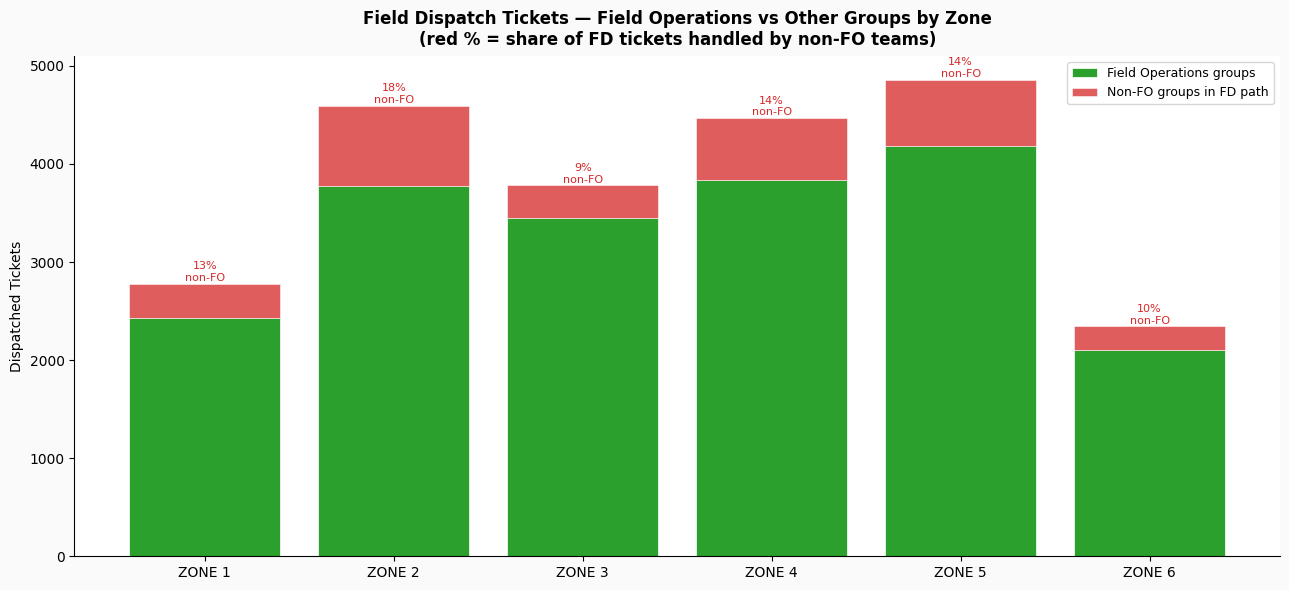

In [6]:
# Field Operations: WOOwnerGroup normalised category (set by pipeline)
FIELD_ENG_GROUPS = ['Field Operations']

if 'WOOwnerGroup' not in df_fd.columns:
    print('WOOwnerGroup not in data — re-run pipeline.')
else:
    fd_attr = df_fd[df_fd['Field_Lead_ID'] != 'Unknown'].copy()
    non_fo  = fd_attr[~fd_attr['WOOwnerGroup'].isin(FIELD_ENG_GROUPS)].copy()

    print(f'FD tickets with attributed Field_Lead_ID: {len(fd_attr):,}')
    print(f'  Field Operations groups:  {len(fd_attr)-len(non_fo):,}')
    print(f'  Non-FO groups in FD path: {len(non_fo):,}  ({len(non_fo)/len(fd_attr)*100:.1f}%)')

    # Breakdown by WOOwnerGroup category and zone
    print(f'\nNon-FO groups breakdown by WOOwnerGroup:')
    grp_stats = (non_fo.groupby('WOOwnerGroup')
        .agg(Tickets=('SLA_Compliant','count'),
             SLA_pct=('SLA_Compliant','mean'),
             Avg_MTTR=('OUTAGEDURATION','mean'))
        .sort_values('Tickets', ascending=False))
    grp_stats['SLA_pct'] *= 100
    print(f'  {"Group":<25} {"Tickets":>8} {"SLA%":>7} {"MTTR":>7}')
    for grp, row in grp_stats.iterrows():
        print(f'  {grp:<25} {int(row["Tickets"]):>8,} '
              f'{row["SLA_pct"]:>6.1f}% {row["Avg_MTTR"]:>6.0f}h')

    # Visual: stacked bar of FD tickets by WOOwnerGroup category per zone
    cat_zone = (fd_attr.groupby(['ZONE','WOOwnerGroup'])
        .size().reset_index(name='Tickets'))
    cat_zone['Is_FO'] = cat_zone['WOOwnerGroup'].isin(FIELD_ENG_GROUPS)
    cat_zone['GroupLabel'] = cat_zone['WOOwnerGroup'].apply(
        lambda x: 'Field Operations' if x in FIELD_ENG_GROUPS else x)

    pivot = (cat_zone.groupby(['ZONE','Is_FO'])['Tickets']
        .sum().unstack(fill_value=0)
        .rename(columns={True:'Field Operations', False:'Other Groups'}))
    pivot = pivot.reindex(ZONE_ORDER)

    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor('#fafafa')
    x = range(len(ZONE_ORDER))
    fo_vals  = pivot['Field Operations'].values
    oth_vals = pivot.get('Other Groups', pivot.iloc[:,0]*0).values
    bars1 = ax.bar(x, fo_vals,  label='Field Operations groups',
                    color='#2ca02c', edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x, oth_vals, bottom=fo_vals,
                    label='Non-FO groups in FD path',
                    color='#d62728', edgecolor='white', linewidth=0.5, alpha=0.75)
    for xi, (fv, ov) in enumerate(zip(fo_vals, oth_vals)):
        total = fv + ov
        if total > 0:
            pct = ov/total*100
            ax.text(xi, total + 30, f'{pct:.0f}%\nnon-FO',
                     ha='center', fontsize=8, color='#d62728')
    ax.set_xticks(x)
    ax.set_xticklabels(ZONE_ORDER, fontsize=10)
    ax.set_title('Field Dispatch Tickets — Field Operations vs Other Groups by Zone\n'
                  '(red % = share of FD tickets handled by non-FO teams)',
                  fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel('Dispatched Tickets', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('reports/figures/project5_ncr/17_fd_group_split.png',
                 dpi=150, bbox_inches='tight')
    plt.show()

## 7. Next Steps

→ **Notebook 18** — Project 5 Business Summary & Recommendations:
site risk scorecard, complexity-adjusted findings, engineer load imbalance,
and targeted PM prioritisation for area heads.

> **Section 6 (above)** quantified non-field-team groups in the FD path:
> 3,035 tickets (13.3%) handled by NOC, Fiber Restoration, Core Operations,
> Engineering, and other groups.